In [1]:
import torch
from pathlib import Path
# from notebooks.utils import get_model, load_model_from_config
from ldm.util import instantiate_from_config
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import default_collate
from ldm.models.diffusion.ddim import DDIMSampler
from ldm.models.diffusion.plms import PLMSSampler
from torchvision.utils import make_grid
from einops import rearrange
from PIL import Image
import pandas as pd

/data/users4/pafshin1/TMPDIR/envs/ldm/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
from pathlib import Path
import torch
from omegaconf import OmegaConf
from ldm.util import instantiate_from_config

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

config_path = Path("/data/users4/pafshin1/Diffusion Models/Large-Image-Diffusion/logs/2025-10-08T00-48-44_Tumor_ssl_vqvae2/configs/2025-10-08T00-48-44-project.yaml")
ckpt_path   = Path("/data/users4/pafshin1/Diffusion Models/Large-Image-Diffusion/logs/2025-10-08T00-48-44_Tumor_ssl_vqvae2/checkpoints/last.ckpt")


In [5]:
config = OmegaConf.load(config_path)

# Remove ckpt_path if present
if "first_stage_config" in config.model.params:
    config.model.params.first_stage_config.params.pop("ckpt_path", None)
if "unet_config" in config.model.params:
    config.model.params.unet_config.params.pop("ckpt_path", None)

def load_model_from_config(config, ckpt, device):
    print(f"Loading model from {ckpt}")
    pl_sd = torch.load(ckpt, map_location="cpu")
    sd = pl_sd["state_dict"]
    model = instantiate_from_config(config.model)
    model.load_state_dict(sd, strict=False)
    model.to(device)
    model.eval()
    return model


In [6]:
model = load_model_from_config(config, ckpt_path, device)
print("Model loaded successfully!")


Loading model from /data/users4/pafshin1/Diffusion Models/Large-Image-Diffusion/logs/2025-10-08T00-48-44_Tumor_ssl_vqvae2/checkpoints/last.ckpt


2025-10-17 02:49:30.045389: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-17 02:49:30.214849: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2025-10-17 02:49:30.214895: I tensorflow/compiler/xla/stream_executor/cuda/cudart_stub.cc:29] Ignore above cudart dlerror if you do not have a GPU set up on your machine.
2025-10-17 02:49:31.830906: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-

No module 'xformers'. Proceeding without it.
LatentDiffusion: Running in eps-prediction mode
DiffusionWrapper has 400.92 M params.
making attention of type 'vanilla' with 512 in_channels
Working with z of shape (1, 3, 64, 64) = 12288 dimensions.
making attention of type 'vanilla' with 512 in_channels
Model loaded successfully!


In [7]:
sampler = PLMSSampler(model)

In [8]:
# sampling params

batch_size = 16
scale = 1.5

ddim_steps = 50
shape = [3,64,64]

In [23]:
meta = pd.read_csv("/data/users4/pafshin1/My_Projects/Combined_Datasets/Combined_Corrected/patches.csv")
meta

,Sample,Index,Row,Column,Label,Edge,Boundary,WSI,Binary_Label
0,2_1_0_0_8400,0,0,8400,N,E,N,2_1,0
1,2_1_1_0_8800,1,0,8800,N,E,N,2_1,0
2,2_1_2_400_6400,2,400,6400,N,E,N,2_1,0
3,2_1_3_400_6800,3,400,6800,N,E,N,2_1,0
4,2_1_4_400_7200,4,400,7200,N,E,N,2_1,0
...,...,...,...,...,...,...,...,...,...
172979,179_1_780_12800_8000,780,12800,8000,T,E,B,179_1,1
172980,179_1_781_12800_8400,781,12800,8400,T,E,B,179_1,1
172981,179_1_782_12800_8800,782,12800,8800,T,E,B,179_1,1
172982,179_1_783_12800_9200,783,12800,9200,N,E,N,179_1,0


In [24]:
import random, numpy as np, torch

seed = 45
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)


In [25]:
from pathlib import Path
import h5py
import numpy as np
from torch.utils.data import Dataset, random_split, DataLoader, WeightedRandomSampler
from PIL import Image
import io
import torch
from torchvision import transforms as T
import pandas as pd
import os
import random
import torch.nn as nn
from sklearn.model_selection import train_test_split
import random
from pathlib import Path
import pandas as pd
import torch
from torch.utils.data import Dataset
from torchvision import transforms as T
from PIL import Image
import random
import torch.nn as nn
from sklearn.model_selection import train_test_split
from PIL import Image
import h5py
from torch.utils.data import Dataset  # just for Dataset base class






from pathlib import Path
import h5py

class CancerDataset2D_Embedding(Dataset):
    def __init__(self, csv_file, path_root, embedding_h5_path, p_uncond=0.0, mode="train", val_split=0.1, seed=42, image_size=256):
        self.path_root = Path(path_root)
        self.metadata = pd.read_csv(csv_file)
        self.embedding_h5 = h5py.File(embedding_h5_path, "r")  # Keep file open
        self.p_uncond = p_uncond
        self.image_size = image_size

        # Split train/val if needed
        if mode in ["train", "val"]:
            from sklearn.model_selection import train_test_split
            train_df, val_df = train_test_split(
                self.metadata,
                test_size=val_split,
                stratify=self.metadata["Binary_Label"],
                random_state=seed
            )
            self.metadata = train_df if mode == "train" else val_df

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        patch_name = f"PS{row['Sample']}.tif"
        img_path = self.path_root / row["WSI"] / patch_name

        # Load image
        img = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32)
        if img.shape[:2] != (self.image_size, self.image_size):
            img = np.array(Image.fromarray(img.astype(np.uint8)).resize((self.image_size, self.image_size)), dtype=np.float32)
        img = img / 127.5 - 1.0

        # Random flips
        if np.random.rand() < 0.5:
            img = np.flip(img, axis=0).copy()
        if np.random.rand() < 0.5:
            img = np.flip(img, axis=1).copy()

        # Load embedding directly using patch name as key
        # full_patch_name = f"{row['WSI']}/{patch_name}"  # matches what we stored in HDF5
        embedding = self.embedding_h5[patch_name][:].astype(np.float32)

        # Optional unconditional embedding
        if np.random.rand() < self.p_uncond:
            embedding = np.zeros_like(embedding)

        return {
            "image": img,
            "feat_patch": embedding,
            "human_label": patch_name   # <-- human-readable patch name
        }


In [74]:

import torch
import numpy as np
import pickle
from torch.utils.data.dataloader import default_collate
from ldm.models.diffusion.plms import PLMSSampler
from torchvision.utils import make_grid
from einops import rearrange
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# --- Load dataset ---
data = CancerDataset2D_Embedding(
    csv_file="/data/users4/pafshin1/My_Projects/Combined_Datasets/Combined_Corrected/patches.csv",
    path_root="/data/users4/pafshin1/My_Projects/Combined_Datasets/Combined_Corrected",
    embedding_h5_path="/data/users4/pafshin1/My_Projects/Combined_Datasets/Combined_Corrected_embedding_fid/Embeddings/ssl_features_dino_cls_new.h5",
    mode="train"
)

# --- Only benign samples ---
benign_indices = [i for i in range(len(data)) if data.metadata.iloc[i]["Binary_Label"] == 0]

# Randomly sample 1000 benign patches
idx = np.random.choice(benign_indices, 1000, replace=False)
items = [data[i] for i in idx]

# Convert images to uint8 for real visualization
for item in items:
    # images are [-1,1], convert to [0,255]
    item['image'] = ((item['image'] + 1.0)/2.0 * 255).astype(np.uint8)

# Optionally save/load for later use
output_path = "/data/users4/pafshin1/Diffusion Models/Large-Image-Diffusion/output/brca_hipt_patches_benign.pickle"
with open(output_path, "wb") as f:
    pickle.dump(items, f)

with open(output_path, "rb") as f:
    items = pickle.load(f)

# --- Prepare a batch ---
batch_size = 4
batch = default_collate(items[:batch_size])

# Convert embeddings to device
batch["feat_patch"] = batch["feat_patch"].to(device)




In [ ]:

ddim_steps = 50
scale = 2.0
shape = [3, 64, 64]

with torch.no_grad(), model.ema_scope():
    batch["feat_patch"] = batch["feat_patch"].to(device)

    batch_uncond = {**batch}
    batch_uncond["feat_patch"] = torch.zeros_like(batch["feat_patch"])

    cc = model.get_learned_conditioning(batch)
    uc = model.get_learned_conditioning(batch_uncond)

    x_T = torch.randn((batch_size, *shape), device=device)
        

    samples_ddim, _ = sampler.sample(
        S=ddim_steps,
        conditioning=cc,
        batch_size=batch_size,
        shape=shape,
        verbose=False,
        unconditional_guidance_scale=scale,
        unconditional_conditioning=uc,
        x_T=x_T
    )

    x_samples_ddim = model.decode_first_stage(samples_ddim)
    x_samples_ddim = torch.clamp((x_samples_ddim + 1.0)/2.0, 0.0, 1.0)
    x_samples_ddim = (x_samples_ddim * 255).to(torch.uint8).cpu()
    samples_real = batch["image"].permute(0,3,1,2)


In [72]:
grid_real =  rearrange(make_grid(samples_real, nrow=4), 'c h w -> h w c').cpu().numpy()
grid_syn =  rearrange(make_grid(x_samples_ddim, nrow=4), 'c h w -> h w c').cpu().numpy()

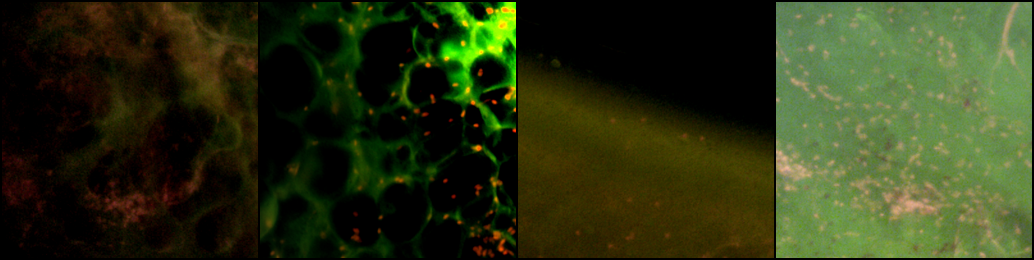

In [76]:
# real images

Image.fromarray(grid_real)

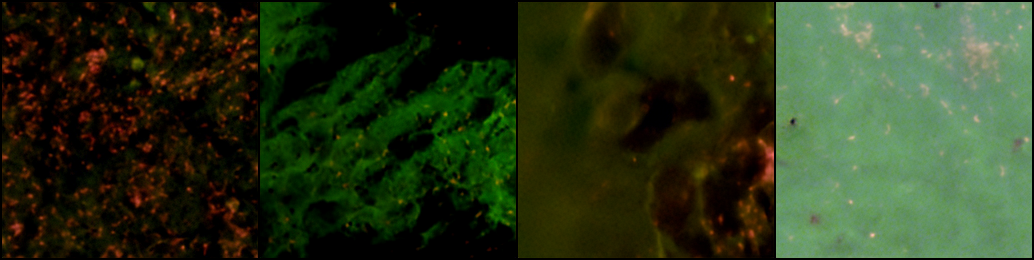

In [77]:

Image.fromarray(grid_syn)